# Lab 7: Multiple Linear Regression
**Author:** 
**Date:** 2026-05-11

___

#### Topic Outline:

- Multiple Linear Regression:
  - Extending SLR to multiple predictors.
  - Fitting a model using `statsmodels`.
  - Interpreting model output: coefficients, adjusted $R^2$, and the F-test.
  - Visualising the fit: actual vs predicted plots.
  - Making new predictions.
  - Residual analysis and model diagnostics.

---

#### Collaboration

You are encouraged to collaborate with other students in your labs, but you are expected to write up your own work for submission.  Please do not copy and paste other people's solutions to problems as it is considered plagiarism and you will be penalized and reported.  Should you choose to collaborate with others, please note their names here:

**Your name: Aldo Nunez** 

**Collaborators:**

1.

___

#### Agent Usage

Additionally, you are permitted to use resources such as ChatGPT and Claude to help you with your lab assignments and to enhance your learning experience.  Please make a note of any agents you have used in this submission here:

**Agents: Claude Code** 

---

## 1. Introduction

In Lab 6 we introduced **Simple Linear Regression (SLR)**, which models the relationship between a single predictor $x$ and a response $y$.  In practice, most phenomena are influenced by *several* variables simultaneously.  **Multiple Linear Regression (MLR)** extends SLR by including $p$ predictor variables $x_1, x_2, \ldots, x_p$:

$$Y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip} + \varepsilon_i, \qquad \varepsilon_i \overset{\text{iid}}{\sim} N(0,\, \sigma^2).$$

### The OLS Estimator

It is convenient to write the MLR model for all $n$ observations simultaneously in **matrix form**:

$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon},$$

where

$$\mathbf{Y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix}, \qquad \mathbf{X} = \begin{pmatrix} 1 & x_{11} & \cdots & x_{1p} \\ 1 & x_{21} & \cdots & x_{2p} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & \cdots & x_{np} \end{pmatrix}, \qquad \boldsymbol{\beta} = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{pmatrix}, \qquad \boldsymbol{\varepsilon} = \begin{pmatrix} \varepsilon_1 \\ \varepsilon_2 \\ \vdots \\ \varepsilon_n \end{pmatrix}.$$

The matrix $\mathbf{X}$ is called the **design matrix** — each row is one observation and the leading column of ones accommodates the intercept $\beta_0$.

The OLS estimator minimises the Residual Sum of Squares $\text{RSS} = \|\mathbf{Y} - \mathbf{X}\boldsymbol{\beta}\|^2$.  Differentiating with respect to $\boldsymbol{\beta}$ and setting the result to zero yields the **normal equations**:

$$\mathbf{X}^\top \mathbf{X}\, \hat{\boldsymbol{\beta}} = \mathbf{X}^\top \mathbf{Y}.$$

Provided $\mathbf{X}^\top \mathbf{X}$ is invertible (i.e. no predictor is an exact linear combination of the others), the unique solution is:

$$\hat{\boldsymbol{\beta}} = \left(\mathbf{X}^\top \mathbf{X}\right)^{-1} \mathbf{X}^\top \mathbf{Y}.$$

This closed-form expression gives the OLS coefficient estimates for all $p + 1$ parameters simultaneously.  The fitted values and residuals are then:

$$\hat{\mathbf{Y}} = \mathbf{X}\hat{\boldsymbol{\beta}}, \qquad \mathbf{e} = \mathbf{Y} - \hat{\mathbf{Y}}.$$

### Statistical Inference

As before, the coefficients are estimated by **Ordinary Least Squares (OLS)**, minimising the Residual Sum of Squares:

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2, \qquad \hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_{i1} + \cdots + \hat{\beta}_p x_{ip}.$$

**Adjusted $R^2$.** Adding predictors always increases the ordinary $R^2$, even if those predictors are useless. The **adjusted $R^2$** penalises for model complexity:

$$\bar{R}^2 = 1 - \frac{\text{RSS}/(n-p-1)}{\text{TSS}/(n-1)}.$$

It can decrease when an additional predictor contributes less than expected by chance, making it a more honest measure of fit when comparing models with different numbers of predictors.

**The F-test.** The overall F-test asks whether *at least one* $\beta_j \neq 0$:

$$H_0: \beta_1 = \beta_2 = \cdots = \beta_p = 0 \qquad \text{vs} \qquad H_1: \text{at least one } \beta_j \neq 0.$$

A significant F-test means the model as a whole explains meaningful variation in $Y$, even if some individual predictors are not significant on their own.

In this lab we will:
1. Introduce two datasets — a worked penguin body-mass example and a California housing exercise.
2. Fit MLR models using `statsmodels` and interpret the output.
3. Visualise the fit using *actual* vs *predicted* plots.
4. Make predictions for new observations.
5. Perform residual analysis to assess model adequacy.

For this lab we will require the following packages:

In [1]:
# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot
from sklearn.datasets import fetch_california_housing

# Seaborn style
sns.set_style("whitegrid")
sns.set_palette("Set2")

---

## 2. The Datasets

In this lab we consider two datasets.  The first is the **Palmer Penguins** dataset, which we use as a worked example to illustrate the full MLR workflow.  The second is the **California Housing** dataset from `scikit-learn`, which you will work through in the exercises.

### 2.1 Dataset 1: Palmer Penguins

We are familiar with the Palmer Penguins data set from previous labs and from lecture.  Last lab we fit a SLR of `body_mass_g` against `flipper_length_mm`.  Now we will look to incorporate multiple covariates. Below we load the data 

In [2]:
# Load penguins, drop rows with missing values
df_penguins = sns.load_dataset('penguins').dropna()
df_penguins.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.00,333.00,333.00,333.00
mean,43.99,17.16,200.97,4207.06
std,5.47,1.97,14.02,805.22
min,32.10,13.10,172.00,2700.00
25%,39.50,15.60,190.00,3550.00
50%,44.50,17.30,197.00,4050.00
75%,48.60,18.70,213.00,4775.00
max,59.60,21.50,231.00,6300.00


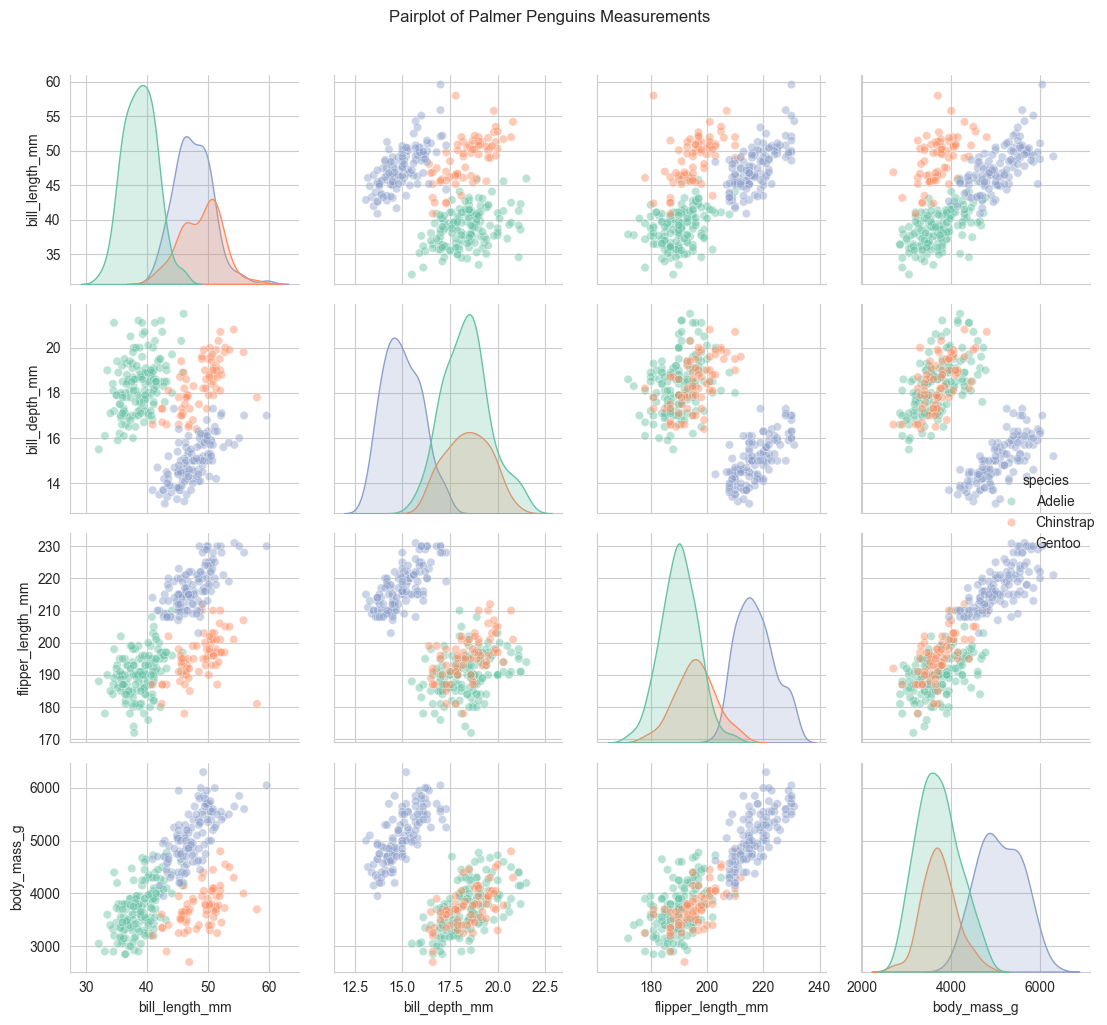

In [3]:
# Pairplot to visualise all pairwise relationships
sns.pairplot(df_penguins, plot_kws={'alpha': 0.45}, hue='species')
plt.suptitle('Pairplot of Palmer Penguins Measurements', y=1.02)
plt.tight_layout()
plt.show()

The pairplot reveals that `flipper_length_mm` has the strongest positive linear relationship with `body_mass_g`.  Both `bill_length_mm` and `bill_depth_mm` also correlate with body mass, though less strongly.  Notably, the three predictors are correlated with each other — particularly `bill_length_mm` and `flipper_length_mm` — a phenomenon called **multicollinearity** that we will revisit when interpreting the model summary.

### 2.2 Dataset 2: California Housing

The California Housing dataset (from `scikit-learn`) contains census data for 20,640 California districts, collected in 1990.  The response variable is `MedHouseVal`, the **median house value in units of \$100,000**.  The dataset contains the following variables:

| Variable | Description |
|---|---|
| `MedInc` | Median household income in the district (tens of thousands of dollars) |
| `HouseAge` | Median age of houses in the district (years) |
| `AveRooms` | Average number of rooms per household in the district |
| `AveBedrms` | Average number of bedrooms per household in the district |
| `Population` | Total population of the district |
| `AveOccup` | Average number of occupants per household in the district |
| `Latitude` | Latitude of the district centroid (degrees north) |
| `Longitude` | Longitude of the district centroid (degrees west, reported as negative) |
| `MedHouseVal` | **Response:** median house value in the district (units of \$100,000) |

In [4]:
# Load California Housing from scikit-learn
housing_data = fetch_california_housing()
df_housing = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
df_housing['MedHouseVal'] = housing_data.target
df_housing.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


`MedHouseVal` ranges from 0.15 to 5.00 (i.e. \$15,000 to \$500,000), with a mean of about \$206,900.  `MedInc` has a wide spread (0.5 to 15.0), while `AveRooms` and `AveOccup` have extreme upper outliers that likely correspond to unusual districts (e.g. hotels or institutions).  Keep these features of the data in mind when interpreting model output.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q0 Exploring the Dataset

1. Display the full dataset description by printing `housing_data.DESCR`.  Read through it and note what you learn about how the data were collected.

2. Produce a figure with **three side-by-side histograms** showing the distributions of `AveRooms`, `AveBedrms`, and `AveOccup`.  Label each axis clearly and give the figure an overall title.  Comment briefly on the shape of each distribution — in particular, note any extreme outliers and what they might represent.

---
**Solution:**

In [5]:
print(housing_data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

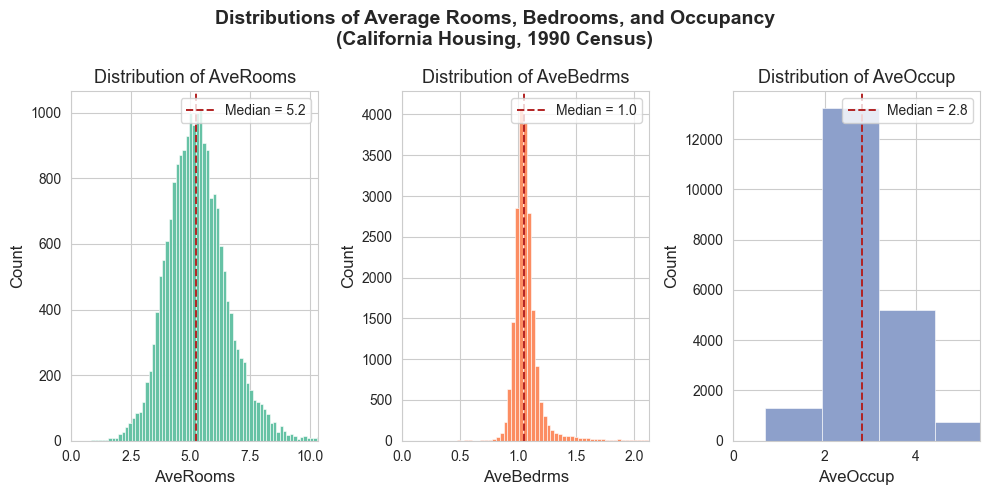

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

vars_to_plot = ['AveRooms', 'AveBedrms', "AveOccup"]
colors = sns.color_palette("Set2", 3)

for ax, var, col in zip(axes, vars_to_plot, colors):
    ax.hist(df_housing[var], bins=1000, color=col, edgecolor='white', linewidth=0.4)
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Distribution of {var}', fontsize=13)
    med = df_housing[var].median()
    ax.axvline(med, color='firebrick', linestyle='--', linewidth=1.4,
               label=f'Median = {med:.1f}')
    ax.legend(fontsize=10)
    ax.set_xlim(left=0, right=df_housing[var].quantile(0.99))

fig.suptitle('Distributions of Average Rooms, Bedrooms, and Occupancy\n'
             '(California Housing, 1990 Census)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. Fitting Multiple Linear Regression Models

In practice we do not invert $\mathbf{X}^\top \mathbf{X}$ by hand — `statsmodels` handles this for us.  Extending the formula API from SLR to MLR is straightforward: simply join the predictor names with `+`:

```python
model = smf.ols('response ~ predictor1 + predictor2 + predictor3', data=df).fit()
```

`statsmodels` automatically constructs the design matrix (including 

Recall from lecture that we found the incorporation of dummy variables for species to improve our model fit.  We therefore fit:

$$\text{body\_mass\_g}_i = \beta_0 + \beta_1 \cdot \text{bill\_length}_i + \beta_2 \cdot \text{bill\_depth}_i + \beta_3 \cdot \text{flipper\_length}_i + \beta_4 \cdot \mathbf{1}[\text{Chinstrap}]_i + \beta_5 \cdot \mathbf{1}[\text{Gentoo}]_i + \varepsilon_i$$

where $\mathbf{1}[\text{Chinstrap}]_i$ and $\mathbf{1}[\text{Gentoo}]_i$ are **dummy variables** that equal 1 when penguin $i$ belongs to the Chinstrap or Gentoo species respectively, and 0 otherwise.  **Adelie is the reference category** — its baseline body mass is captured by the intercept $\beta_0$.  The coefficients $\beta_4$ and $\beta_5$ each measure the expected difference in body mass between that species and an Adelie, **holding bill length, bill depth, and flipper length fixed**.  `statsmodels` selects the reference category alphabetically and labels the dummy columns `C(species)[T.Chinstrap]` and `C(species)[T.Gentoo]` in the summary output.

and inspect the output:

In [24]:
# Fit MLR model for penguins (species included as dummy variables)
model_p = smf.ols(
    'body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + C(species)',
    data=df_penguins
).fit()
print(model_p.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     369.1
Date:                Fri, 15 May 2026   Prob (F-statistic):          4.22e-132
Time:                        16:20:34   Log-Likelihood:                -2384.8
No. Observations:                 333   AIC:                             4782.
Df Residuals:                     327   BIC:                             4805.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -4

The key quantities to extract from the summary are:

| Field | Location in output | Interpretation |
|---|---|---|
| `coef` — `Intercept` | Coefficients table | $\hat{\beta}_0$: predicted body mass for an **Adelie** when all continuous predictors equal zero (not physically meaningful) |
| `coef` — continuous predictors | Coefficients table | $\hat{\beta}_j$: expected change in body mass (g) per 1-unit increase in $x_j$, **holding species and all other predictors fixed** |
| `coef` — `C(species)[T.Chinstrap]` | Coefficients table | $\hat{\beta}_4$: expected difference in body mass between a Chinstrap and an Adelie with the **same** bill and flipper measurements |
| `coef` — `C(species)[T.Gentoo]` | Coefficients table | $\hat{\beta}_5$: expected difference in body mass between a Gentoo and an Adelie with the **same** bill and flipper measurements |
| `P>\|t\|` | Coefficients table | p-value for $H_0: \beta_j = 0$ |
| `Adj. R-squared` | Top block | $R^2$ penalised for number of predictors — more honest for MLR |
| `F-statistic` | Top block | Test that at least one $\beta_j \neq 0$ |

**Interpreting this model:**

- **Species dummies:** the large positive coefficient on `C(species)[T.Gentoo]` reflects the well-known fact that Gentoos are substantially heavier than Adelies for a given set of bill and flipper measurements.  The Chinstrap coefficient is much smaller in magnitude, indicating Chinstraps are similar in mass to Adelies once bill and flipper size are controlled for.  Both species effects are highly significant.

- **Continuous predictors:** notice that once species is included, the coefficients on `bill_length_mm` and `bill_depth_mm` change substantially compared to the species-free model — and become significant.  This is because species was acting as a **confounder**: without it in the model, the bill measurements were partly proxying for between-species differences in body size rather than within-species variation.

- **Adjusted $R^2$:** the model explains considerably more variance in body mass than the species-free version (which had $\bar{R}^2 = 0.762$), confirming what was demonstrated in lecture — species is an important predictor that should not be omitted.

- **The F-test** ($p \approx 0$) confirms the model as a whole is highly significant.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q1 Fitting a Model

Fit an MLR model to the California Housing data with `MedHouseVal` as the response and `MedInc`, `HouseAge`, `AveRooms`, and `AveOccup` as predictors.  Print the model summary and answer the following:

1. Which predictor has the largest (in magnitude) t-statistic?  What does this tell us?
2. Interpret the coefficient on `AveRooms`.  Does its sign surprise you?  Why might it be negative when holding the other variables fixed?
3. Report the adjusted $R^2$.  What percentage of the variance in median house value is explained by these four predictors?
4. What does the F-test tell us?

---
**Solution:**

In [ ]:
model_h = smf.ols(
    'MedHouseVal ~ MedInc + HouseAge + AveRooms + AveOccup',
    data = df_housing
).fit()
print(model_h.summary())


                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     5450.
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        16:27:49   Log-Likelihood:                -24802.
No. Observations:               20640   AIC:                         4.961e+04
Df Residuals:                   20635   BIC:                         4.965e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0314      0.022      1.428      0.1

1. The predictor that has the largest |t| is MedInc so this tells us that income is by far the strongest predictor

2. The negative sign on AveRooms doesn't surprise me since once income is conrolled for, more rooms per district correlates with lower-density, lower-price areas.

3. The adjusted $R^2$ is 0.514. This means that 51.4% of the variance in median house value is explained by the four predictors

4. Since p < 0.05, the F test tells us that the model is highly significant

---

## 4. Visualising the Fit: Actual vs Predicted

With a single predictor we could plot the fitted line directly on a scatter plot.  With multiple predictors this is no longer possible — the fitted surface lives in a higher-dimensional space.  Instead, the standard visualisation for MLR is the **actual vs predicted plot**: a scatter plot of the observed response $y_i$ against the fitted values $\hat{y}_i$.

If the model fits well, the points should cluster tightly around the **diagonal reference line** $y = \hat{y}$ (perfect prediction).  Systematic deviations — such as curvature, fan shapes, or points concentrated above or below the line — signal model misspecification or heteroscedasticity.

The fitted values are stored in `model.fittedvalues` after calling `.fit()`.

For the penguins model we plot observed body mass against fitted body mass:

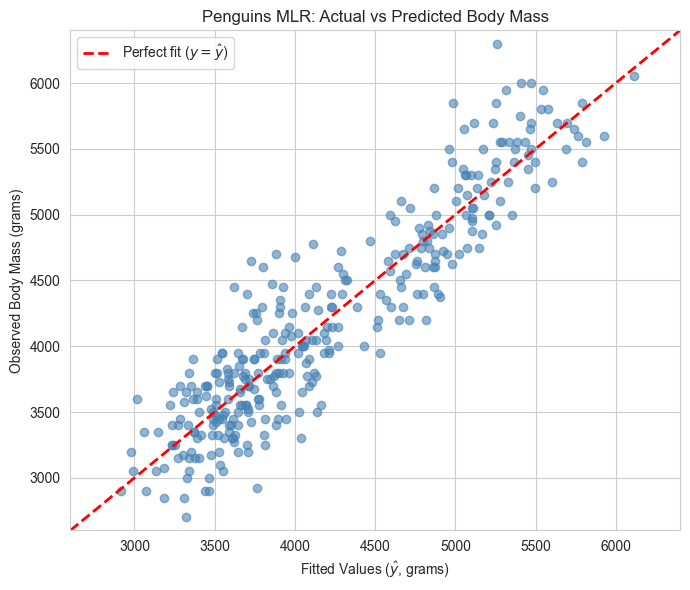

In [32]:
# Actual vs Predicted for penguins
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(model_p.fittedvalues, df_penguins['body_mass_g'], alpha=0.6, color='steelblue')

# Diagonal reference line
lims = [
    min(model_p.fittedvalues.min(), df_penguins['body_mass_g'].min()) - 100,
    max(model_p.fittedvalues.max(), df_penguins['body_mass_g'].max()) + 100
]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit ($y = \\hat{y}$)')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Fitted Values ($\\hat{y}$, grams)')
ax.set_ylabel('Observed Body Mass (grams)')
ax.set_title('Penguins MLR: Actual vs Predicted Body Mass')
ax.legend()
plt.tight_layout()
plt.show()

The points cluster more tightly around the diagonal than they did in the species-free model, consistent with the higher adjusted $R^2$ achieved by including species.  The spread is roughly constant across the range of fitted values with no obvious curvature — a positive sign for the linearity and homoscedasticity assumptions.  Any remaining tendency to under-predict the heaviest or over-predict the lightest penguins will be investigated in the residual analysis.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2 Actual vs Predicted Plot

Produce an actual vs predicted plot for the California Housing model.  Include the diagonal reference line.  Comment on:
1. How tightly the points cluster around the diagonal (does this match the $R^2$ value?).
2. Whether there is any systematic pattern (curvature, fan shape, clustering above or below the line).

---
**Solution:**

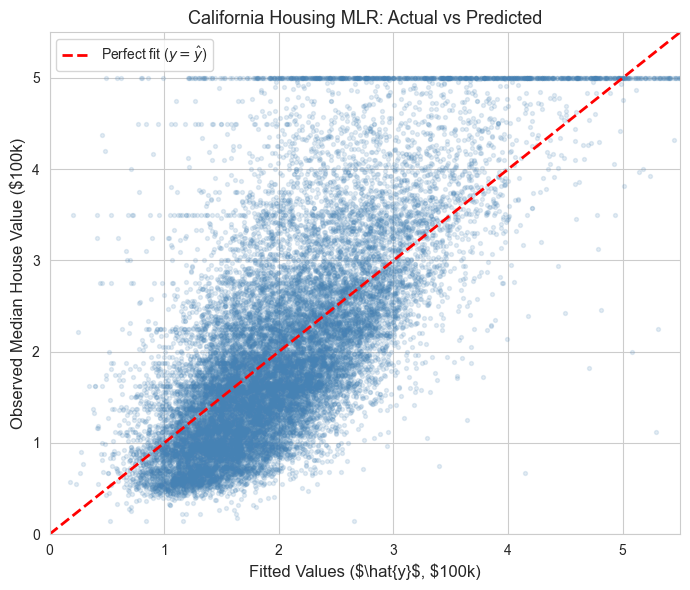

In [39]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(model_h.fittedvalues, df_housing['MedHouseVal'],
           alpha=0.15, s=8, color='steelblue', rasterized=True)

lims = [0, 5.5]  
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit ($y = \\hat{y}$)')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Fitted Values ($\\hat{y}$, $100k)', fontsize=12)
ax.set_ylabel('Observed Median House Value ($100k)', fontsize=12)
ax.set_title('California Housing MLR: Actual vs Predicted', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

1. Points cluster around the diagonal but with substantial scatter which matches the ~0.49 $R^2$
2. There is a ceiling effect at 5.0 as well as a fan shape which indicates heteroscedasticity

---

## 5. Making New Predictions

Predictions in MLR work exactly as in SLR: pass a `DataFrame` containing the new predictor values (with the same column names as in the model formula) to `.get_prediction().summary_frame()`.  The key difference is that we now must specify a value for **each** predictor in the model.

In [35]:
# New penguins to predict body mass for (species must be specified)
new_penguins = pd.DataFrame({
    'bill_length_mm':    [39.5, 46.5, 52.0],
    'bill_depth_mm':     [15.7, 17.9, 19.5],
    'flipper_length_mm': [187,  203,  221],
    'species':           ['Adelie', 'Chinstrap', 'Gentoo']
})

# Full prediction summary: point estimate + CI + PI
pred_p = model_p.get_prediction(new_penguins).summary_frame(alpha=0.05)
pred_p.index = ['Penguin A (Adelie)', 'Penguin B (Chinstrap)', 'Penguin C (Gentoo)']

# Select and rename for readability
pred_p = pred_p[['mean', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']]
pred_p.columns = ['Body Mass (g)', 'CI Lower', 'CI Upper', 'PI Lower', 'PI Upper']
pred_p.round(1)

,Body Mass (g),CI Lower,CI Upper,PI Lower,PI Upper
Penguin A (Adelie),3295.0,3182.3,3407.6,2665.6,3924.3
Penguin B (Chinstrap),3711.7,3611.6,3811.9,3084.5,4339.0
Penguin C (Gentoo),5983.1,5824.9,6141.2,5344.0,6622.1


The three hypothetical penguins each belong to a different species, which now contributes directly to the prediction alongside the continuous measurements.  Note that when making predictions from a model that includes species, a species value must be specified for each new observation — the model cannot impute it.

- **Penguin A (Adelie)** has small bills and short flippers typical of an Adelie; the species dummy contributes zero (Adelie is the reference category), so the prediction is driven entirely by the continuous terms.
- **Penguin B (Chinstrap)** has mid-range measurements; the Chinstrap dummy shifts the prediction by $\hat{\beta}_4$ relative to an Adelie with the same measurements.
- **Penguin C (Gentoo)** has large bills and long flippers typical of a Gentoo; the large positive Gentoo dummy pushes the predicted mass substantially higher than the continuous measurements alone would suggest.

As before, prediction intervals are considerably wider than confidence intervals, and all predicted values should fall within the observed range of `body_mass_g` (2,700 g – 6,300 g), confirming we are interpolating rather than extrapolating.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3 Making Predictions

Use your fitted housing model to predict the median house value (and associated 95% CI and PI) for the four districts described below.  Present the results in a readable table and comment on:

1. How does predicted house value change as `MedInc` increases from 2.5 to 12.0?
2. Home A's prediction interval extends below zero.  What does this mean, and why does it happen?

| District | MedInc | HouseAge | AveRooms | AveOccup |
|---|---|---|---|---|
| Home A | 2.5 | 10 | 4.0 | 2.5 |
| Home B | 5.0 | 25 | 5.5 | 2.8 |
| Home C | 8.0 | 35 | 6.5 | 3.0 |
| Home D | 12.0 | 50 | 7.0 | 3.5 |

---
**Solution:**

In [38]:
new_districts = pd.DataFrame({
    'MedInc':   [2.5,  5.0,  8.0,  12.0],
    'HouseAge': [10,   25,   35,   50],
    'AveRooms': [4.0,  5.5,  6.5,  7.0],
    'AveOccup': [2.5,  2.8,  3.0,  3.5],
})
pred_h = model_h.get_prediction(new_districts).summary_frame(alpha=0.05)
pred_h.index = ['Home A', 'Home B', 'Home C', 'Home D']
pred_h = pred_h[['mean', 'mean_ci_lower', 'mean_ci_upper',
                  'obs_ci_lower', 'obs_ci_upper']]
pred_h.columns = ['Predicted ($100k)', 'CI Lower', 'CI Upper',
                  'PI Lower', 'PI Upper']
print(pred_h.round(3).to_string())

        Predicted ($100k)  CI Lower  CI Upper  PI Lower  PI Upper
Home A              1.188     1.165     1.211     -0.39     2.766
Home B              2.507     2.494     2.520      0.93     4.085
Home C              3.978     3.950     4.005      2.40     5.555
Home D              5.988     5.934     6.043      4.41     7.567


1. Predicted value rises substantially as MedInc goes from 2.5 to 12.0, specifically, from 1.118 to 5.999, a 481k difference.

2. Home A's PI extends below zero becuase PI captures individual district uncertainty. Essentially, residual std error is large relative to a low prediction. 

---

## 6. Residual Analysis

The assumptions of MLR are the same as for SLR:

1. **Linearity**: the true relationship between each $x_j$ and $y$ is linear (after conditioning on the other predictors).
2. **Independence**: the errors $\varepsilon_i$ are independent.
3. **Homoscedasticity**: the errors have constant variance $\sigma^2$.
4. **Normality**: the errors follow a normal distribution.

We diagnose these assumptions using the same two plots as in Lab 6:

- **Residuals vs Fitted plot**: residuals $e_i = y_i - \hat{y}_i$ plotted against fitted values $\hat{y}_i$.  A random scatter around zero is ideal; systematic patterns indicate violated assumptions.
- **Normal Q-Q plot**: quantiles of the residuals against theoretical normal quantiles.  Points close to the diagonal support the normality assumption.

We produce these diagnostic plots for the penguins model:

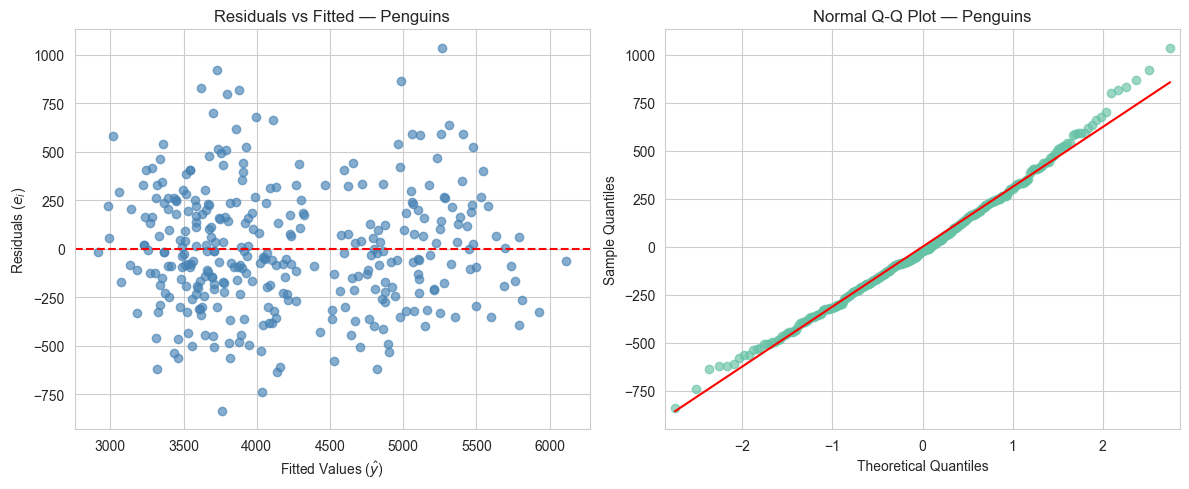

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Fitted
axes[0].scatter(model_p.fittedvalues, model_p.resid, alpha=0.65, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Fitted Values ($\\hat{y}$)')
axes[0].set_ylabel('Residuals ($e_i$)')
axes[0].set_title('Residuals vs Fitted — Penguins')

# Normal Q-Q plot
qqplot(model_p.resid, line='s', ax=axes[1], alpha=0.65)
axes[1].set_title('Normal Q-Q Plot — Penguins')

plt.tight_layout()
plt.show()

For the penguins model with species:
- **Residuals vs Fitted**: the residuals scatter approximately randomly around zero with no strong curvature or fan shape — consistent with linearity and homoscedasticity.  Including species removes the systematic between-species variation in body mass that would otherwise appear as structured clustering in the residuals.
- **Q-Q plot**: the points follow the diagonal well across the central bulk of the data.  The slight deviations at the tails are mild and expected with a sample of this size.

Overall, the assumptions are adequately satisfied for this model.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q4 Residual Analysis

Reproduce these diagnostic plots for the California Housing model.  What patterns do you observe in each plot?  What assumptions appear to be violated, and what does this suggest about the model?

---
**Solution:**

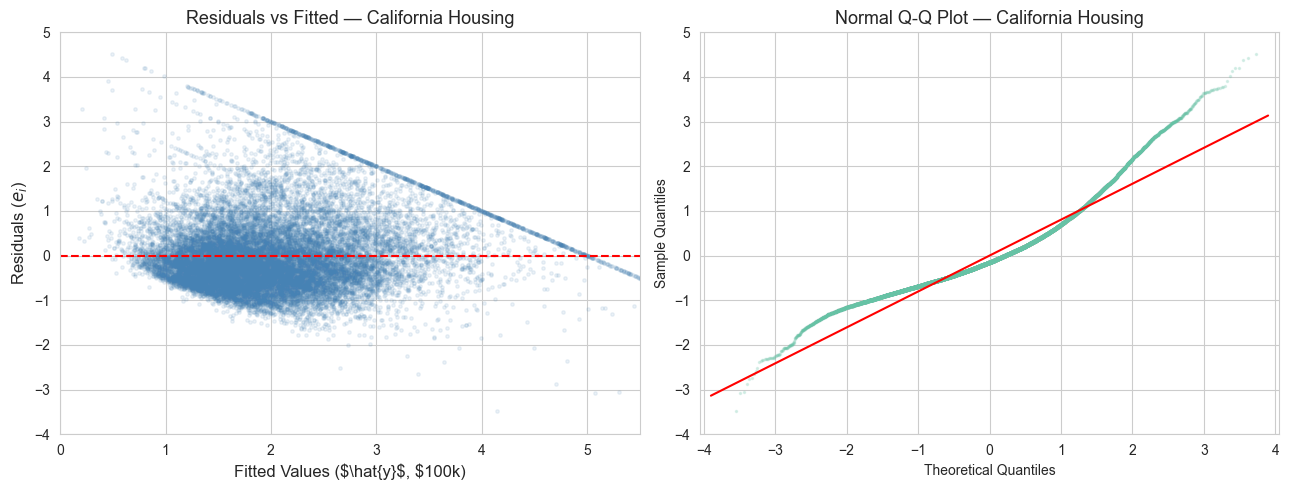

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Fitted
axes[0].scatter(model_h.fittedvalues, model_h.resid,
                alpha=0.10, s=6, color='steelblue', rasterized=True)
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlim([0, 5.5])          
axes[0].set_ylim([-4, 5])          
axes[0].set_xlabel('Fitted Values ($\\hat{y}$, $100k)', fontsize=12)
axes[0].set_ylabel('Residuals ($e_i$)', fontsize=12)
axes[0].set_title('Residuals vs Fitted — California Housing', fontsize=13)

# Normal Q-Q plot
qqplot(model_h.resid, line='s', ax=axes[1], alpha=0.20,
       marker='.', markersize=3)
axes[1].set_ylim([-4, 5])           
axes[1].set_title('Normal Q-Q Plot — California Housing', fontsize=13)

plt.tight_layout()
plt.show()

In the residuals vs fitted plot, I notice a fan shape which indicated heteroscedasticity as well as a band of positive residuals which is just he 500k capped observations. The Q-Q plot shows clear violations of normality since the observations don't follow the line.

---

## Submission Checklist

- Ensure you have completed all problems in the notebook.
- Clear your document code outputs and rerun the notebook from top to bottom, checking for any new errors.
- At the top of your notebook click more options -> export -> pdf.
  - Alternatively, export to html and save as a pdf.
- Make sure your pdf has all code chunks clearly visible and executed.
- Submit before the posted deadline.